#### Даалгавар: Өгөгдсөн өгөгдлүүдийг ашиглан бизнестэй холбоотой асуудал эсвэл боломжийг таамаглаж, санал бэлтгэх

Хүлээгдэж бүй үр дүн:
- Шинжилгээний танилцуулга
- Олж илрүүлсэн түлхүүр insight
- Хэрэгжүүлэх боломжтой санал 

### Importing neccessary dependencies & Exploratory Data Analysis

In [163]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
#дэлгүүрүүдийн өгөгдөл
branch = pd.read_csv("branch_master.csv")
#харилцагчдын өгөгдөл
customers = pd.read_csv("customers.csv")
#агуулахын өгөгдөл
inventory = pd.read_csv("inventory_daily.csv")
#бүтээгдэхүүний ангиллын өгөгдөл
product = pd.read_csv("product_master.csv")
#худалдан авалт түвшний өгөгдөл
sales = pd.read_csv("sales_transaction.csv")
# худалдан авсан бүтээгдэхүүний түвшний өгөгдөл
line = pd.read_csv("sales_transactionline.csv")
#харилцагчийн судалгаа
survey = pd.read_csv("survey_feedback.csv")


In [87]:
branch.head(2)

,branch_id,branch_name,zone,store_size
0,B01,Branch 1,Downtown,Medium
1,B02,Branch 2,Office district,Medium


In [88]:
customers.head(2)

,customer_id,join_date,seed_segment,gender,age,loyalty_channel
0,C0001,2024-05-31,Morning commuter,F,41,App
1,C0002,2023-05-22,Morning commuter,F,31,Card


In [89]:
inventory.head(2)

,inventory_date,branch_id,product_code,on_hand_qty,reorder_point,stock_flag
0,2025-01-01,B01,SNK004,29,36,OK
1,2025-01-01,B01,DES003,22,26,LOW


In [90]:
product.head(2)

,product_code,product_name,category_code,category_name,base_price,brand_type,margin_band
0,SNK001,Potato Chips Sea Salt,SNK,Snacks,3800,Import,A
1,SNK002,Corn Chips Spicy,SNK,Snacks,4200,Import,C


In [91]:
sales.head(2)

,transaction_id,transaction_ts,sales_date,branch_id,customer_id,payment_method,basket_amount
0,T0000001,2025-01-01 10:34:15,2025-01-01,B02,C0086,cash,7200
1,T0000002,2025-01-01 18:31:46,2025-01-01,B01,C0026,wallet,14300


In [92]:
line.head(2)

,line_id,transaction_id,product_code,qty,unit_price,discount_amt,line_amount
0,L00000001,T0000001,BEV003,1,4000,200,3800
1,L00000002,T0000001,DES003,1,3700,300,3400


In [93]:
survey.head(2)

,feedback_id,feedback_date,branch_id,product_code,quality_score,visual_score,would_buy_again,what_to_improve,general_thoughts
0,F00001,2025-01-27,B01,RTE002,7,7,yes,bundle with drink,liked the freshness
1,F00002,2025-01-06,B05,HOU002,6,8,no,keep same quality,quick and convenient


### Creating the main dataframe by joining

In [94]:
sales_enriched = (
    sales
    .merge(
        branch[["branch_id", "branch_name", "zone", "store_size"]],
        on="branch_id",
        how="left"
    )
    .merge(
        customers[["customer_id", "gender", "age", "seed_segment", "loyalty_channel"]],
        on="customer_id",
        how="left"
    )
)

In [95]:
sales_line = (
    line
    .merge(
        sales_enriched,
        on="transaction_id",
        how="left"
    )
    .merge(
        product[[
            "product_code", "product_name", "category_code", "category_name",
            "base_price", "brand_type", "margin_band"
        ]],
        on="product_code",
        how="left"
    )
)


In [96]:
df = sales_line.copy()

#### Хамгийн их зарагддаг product category юу вэ?

In [97]:
df["category_name"].value_counts()

category_name
Beverage      2930
ReadyToEat    2868
Snacks        2819
Dessert       2159
Household     2138
Name: count, dtype: int64

In [98]:
cat_perf = df.groupby(['category_name']).agg(
    revenue=('line_amount', 'sum'),
    units=('qty', 'sum'),
    transactions=('transaction_id', 'nunique')
).reset_index().sort_values('revenue', ascending=False)

cat_perf.head(10)

,category_name,revenue,units,transactions
3,ReadyToEat,23940900,3578,2278
4,Snacks,13864400,3552,2244
1,Dessert,11005600,2719,1802
2,Household,10540200,2656,1815
0,Beverage,9842800,3679,2294


#### Customer Segment

In [99]:
df["age"].median()

np.float64(36.0)

In [100]:
df["age"].mean()

np.float64(36.47583263753595)

In [101]:
df["gender"].value_counts()

gender
M    5669
F    5110
Name: count, dtype: int64

In [102]:
df.columns

Index(['line_id', 'transaction_id', 'product_code', 'qty', 'unit_price',
       'discount_amt', 'line_amount', 'transaction_ts', 'sales_date',
       'branch_id', 'customer_id', 'payment_method', 'basket_amount',
       'branch_name', 'zone', 'store_size', 'gender', 'age', 'seed_segment',
       'loyalty_channel', 'product_name', 'category_code', 'category_name',
       'base_price', 'brand_type', 'margin_band'],
      dtype='str')

### Хэрэглэгчийн ангилал

In [103]:
segment_perf = df.groupby(['seed_segment']).agg(
    revenue=('line_amount', 'sum'),
    transactions=('transaction_id', 'nunique'),
    customers=('customer_id', 'nunique'),
    units=('qty', 'sum')
).reset_index()

segment_perf['avg_rev_per_txn'] = segment_perf['revenue'] / segment_perf['transactions']
segment_perf['avg_rev_per_customer'] = segment_perf['revenue'] / segment_perf['customers']

segment_perf.sort_values('revenue', ascending=False)

,seed_segment,revenue,transactions,customers,units,avg_rev_per_txn,avg_rev_per_customer
4,Student value seeker,16054200,1173,34,3772,13686.445013,472182.352941
3,Morning commuter,13865100,1016,27,3206,13646.751969,513522.222222
2,Lunch office,12125800,902,26,2834,13443.237251,466376.923077
1,Healthy routine,9088300,677,18,2098,13424.372230,504905.555556
0,Family stock-up,6666700,505,15,1581,13201.386139,444446.666667


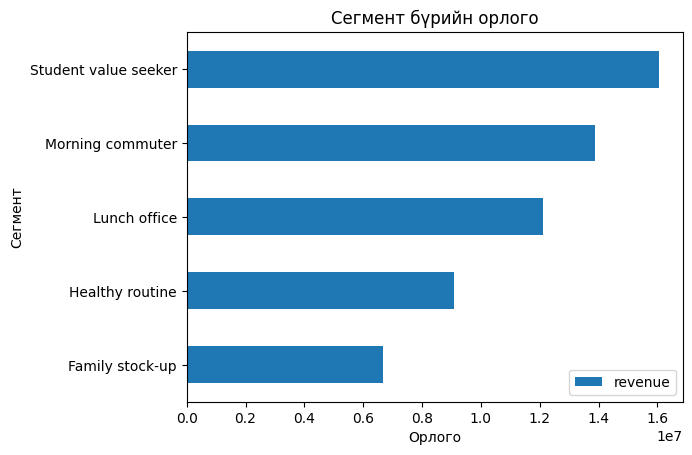

In [155]:
segment_perf.sort_values('revenue').plot(
    kind='barh',
    x='seed_segment',
    y='revenue'
)

plt.title("Сегмент бүрийн орлого")
plt.xlabel("Орлого")
plt.ylabel("Сегмент")
plt.show()

#### Салбаруудын нийт орлого

In [146]:
branch_perf = df.groupby(['branch_name', 'zone', 'store_size']).agg(
    revenue=('line_amount', 'sum'),
    transactions=('transaction_id', 'nunique'),
    units=('qty', 'sum'),
    customers=('customer_id', 'nunique')
).reset_index()

branch_perf['avg_basket'] = branch_perf['revenue'] / branch_perf['transactions']



#### Сегмент бүр ямар категорийг их сонгодог вэ?

In [125]:
seg_cat = df.groupby(['seed_segment', 'category_name']).agg(
    revenue=('line_amount', 'sum'),
    units=('qty', 'sum'),
    transactions=('transaction_id', 'nunique')
).reset_index().sort_values('revenue', ascending=False)

seg_cat.head(20)

,seed_segment,category_name,revenue,units,transactions
23,Student value seeker,ReadyToEat,5608900,843,536
18,Morning commuter,ReadyToEat,4842900,723,469
13,Lunch office,ReadyToEat,4261700,630,404
24,Student value seeker,Snacks,3230100,828,521
8,Healthy routine,ReadyToEat,3197000,476,307
19,Morning commuter,Snacks,2669000,684,438
21,Student value seeker,Dessert,2474400,622,412
22,Student value seeker,Household,2463000,619,415
14,Lunch office,Snacks,2327900,594,378
20,Student value seeker,Beverage,2277800,860,533


Student value seeker сегмент хамгийн өндөр орлогыг бүрдүүлж байгаа бөгөөд хамгийн олон худалдан авалт хийж байна. Энэ нь тухайн сегмент бизнесийн гол орлогын эх үүсвэр болж байгааг харуулж байна.

### Хямдралтай бүтээгдэхүүнүүд

In [147]:
df['discount_pct'] = df['discount_amt'] / (df['qty'] * df['unit_price'])
df['discount_pct'] = df['discount_pct'].fillna(0)

In [127]:
discount_perf = df.groupby('category_name').agg(
    revenue=('line_amount', 'sum'),
    avg_discount_pct=('discount_pct', 'mean')
).reset_index().sort_values('revenue', ascending=False)

discount_perf.head(10)

,category_name,revenue,avg_discount_pct
3,ReadyToEat,23940900,0.022772
4,Snacks,13864400,0.037754
1,Dessert,11005600,0.037640
2,Household,10540200,0.044684
0,Beverage,9842800,0.058677


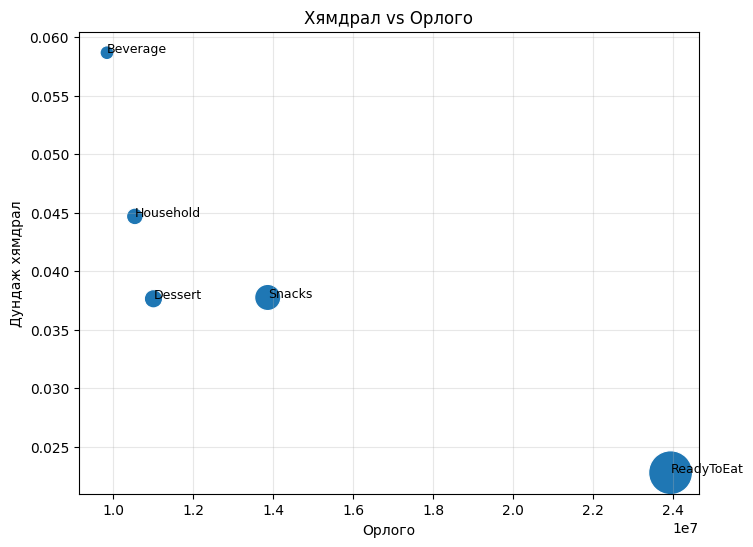

In [166]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=discount_perf,
    x='revenue',
    y='avg_discount_pct',
    size='revenue',
    sizes=(100, 1000),
    legend=False
)

for i in range(len(discount_perf)):
    plt.text(
        discount_perf['revenue'][i],
        discount_perf['avg_discount_pct'][i],
        discount_perf['category_name'][i],
        fontsize=9
    )

plt.xlabel("Орлого")
plt.ylabel("Дундаж хямдрал")
plt.title("Хямдрал vs Орлого")
plt.grid(alpha=0.3)

plt.show()

Ready-to-eat бүтээгдэхүүнүүд хамгийн өндөр орлогыг бүрдүүлж байгаа хэдий ч хамгийн бага discount-тай байна. Энэ нь тухайн ангилал өндөр эрэлттэй бөгөөд discount-гүйгээр ч сайн борлуулагдаж байгааг харуулж байна.

### Сегмент бүрийн хямдрал

In [128]:
seg_discount = df.groupby('seed_segment').agg(
    revenue=('line_amount', 'sum'),
    avg_discount=('discount_pct', 'mean'),
    transactions=('transaction_id', 'nunique'),
    customers=('customer_id', 'nunique')
).reset_index()

seg_discount['rev_per_customer'] = seg_discount['revenue'] / seg_discount['customers']

seg_discount.sort_values('revenue', ascending=False)

,seed_segment,revenue,avg_discount,transactions,customers,rev_per_customer
4,Student value seeker,16054200,0.040223,1173,34,472182.352941
3,Morning commuter,13865100,0.038359,1016,27,513522.222222
2,Lunch office,12125800,0.040002,902,26,466376.923077
1,Healthy routine,9088300,0.041665,677,18,504905.555556
0,Family stock-up,6666700,0.039870,505,15,444446.666667


In [129]:
survey.columns

Index(['feedback_id', 'feedback_date', 'branch_id', 'product_code',
       'quality_score', 'visual_score', 'would_buy_again', 'what_to_improve',
       'general_thoughts', 'would_buy_again_flag'],
      dtype='str')

In [130]:
survey_df = survey.merge(
    product[['product_code', 'product_name', 'category_name']],
    on='product_code',
    how='left'
).merge(
    branch[['branch_id', 'branch_name', 'zone', 'store_size']],
    on='branch_id',
    how='left'
)

In [135]:
survey_df['would_buy_again_flag'] = survey_df['would_buy_again'].map({
    'yes': 1,
    'no': 0,
    'maybe': 0.5
})

In [136]:
survey_df

,feedback_id,feedback_date,branch_id,product_code,quality_score,visual_score,would_buy_again,what_to_improve,general_thoughts,would_buy_again_flag,product_name,category_name,branch_name,zone,store_size
0,F00001,2025-01-27,B01,RTE002,7,7,yes,bundle with drink,liked the freshness,1.0,Tuna Kimbap,ReadyToEat,Branch 1,Downtown,Medium
1,F00002,2025-01-06,B05,HOU002,6,8,no,keep same quality,quick and convenient,0.0,Tissue Pack,Household,Branch 5,University,Small
2,F00003,2025-01-01,B05,RTE002,7,4,maybe,more flavor options,good value for money,0.5,Tuna Kimbap,ReadyToEat,Branch 5,University,Small
3,F00004,2025-02-16,B01,BEV002,10,6,yes,keep same quality,liked the freshness,1.0,Sparkling Water,Beverage,Branch 1,Downtown,Medium
4,F00005,2025-01-29,B02,HOU001,4,6,yes,freshness issue,quality felt inconsistent,1.0,Wet Wipes,Household,Branch 2,Office district,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,F00896,2025-02-26,B01,HOU002,7,7,maybe,more flavor options,liked the freshness,0.5,Tissue Pack,Household,Branch 1,Downtown,Medium
896,F00897,2025-02-11,B04,BEV004,7,6,yes,better promotion visibility,quick and convenient,1.0,Green Tea Bottle,Beverage,Branch 4,Residential west,Small
897,F00898,2025-02-22,B01,DES001,8,6,no,bundle with drink,liked the freshness,0.0,Yogurt Cup,Dessert,Branch 1,Downtown,Medium
898,F00899,2025-03-16,B03,BEV002,5,6,no,packaging damaged,quality felt inconsistent,0.0,Sparkling Water,Beverage,Branch 3,Residential east,Small


#### Бүтээгдэхүүний ангиллын сэтгэл ханамж


In [150]:
cat_survey = survey_df.groupby('category_name').agg(
    quality_score=('quality_score', 'mean'),
    visual_score=('visual_score', 'mean'),
    buy_again_rate=('would_buy_again_flag', 'mean'),
    responses=('feedback_id', 'count')
).reset_index().sort_values('quality_score')

In [151]:
cat_survey

,category_name,quality_score,visual_score,buy_again_rate,responses
0,Beverage,6.512563,6.522613,0.545226,199
2,Household,6.598684,6.605263,0.588816,152
3,ReadyToEat,6.742574,6.252475,0.574257,202
4,Snacks,6.796954,6.629442,0.527919,197
1,Dessert,7.053333,6.346667,0.613333,150


Ready-to-eat ангилал хамгийн өндөр орлоготой боловч хэрэглэгчийн сэтгэл ханамж (buy-again rate ~57%) харьцангуй дундаж түвшинд байна.

### Салбарын сэтгэл ханамж


In [ ]:
branch_survey = survey_df.groupby('branch_name').agg(
    quality_score=('quality_score', 'mean'),
    visual_score=('visual_score', 'mean'),
    buy_again_rate=('would_buy_again_flag', 'mean'),
    responses=('feedback_id', 'count')
).reset_index().sort_values('quality_score')

In [142]:
branch_survey

,branch_name,quality_score,visual_score,buy_again_rate,responses
2,Branch 3,6.584507,6.753521,0.598592,142
3,Branch 4,6.597561,6.530488,0.515244,164
1,Branch 2,6.681481,6.333333,0.577778,135
5,Branch 6,6.817610,6.515723,0.581761,159
4,Branch 5,6.820000,6.280000,0.540000,150
0,Branch 1,6.880000,6.400000,0.593333,150


#### Product-level

In [143]:
product_survey = survey_df.groupby('product_name').agg(
    quality_score=('quality_score', 'mean'),
    buy_again_rate=('would_buy_again_flag', 'mean'),
    responses=('feedback_id', 'count')
).reset_index().sort_values('quality_score')

In [144]:
product_survey

,product_name,quality_score,buy_again_rate,responses
9,Iced Coffee,6.283019,0.537736,53
12,Protein Bar,6.394737,0.447368,38
3,Chicken Sandwich,6.470588,0.519608,51
7,Green Tea Bottle,6.488889,0.544444,45
5,Cola 500ml,6.500000,0.482143,56
14,Tissue Pack,6.549020,0.598039,51
16,Wet Wipes,6.600000,0.527273,55
0,Batteries AA,6.652174,0.652174,46
10,Pasta Box,6.745098,0.558824,51
8,Ice Cream Bar,6.785714,0.619048,42


### Survey + Sales холболт

In [145]:
# sales side
cat_sales = df.groupby('category_name').agg(
    revenue=('line_amount', 'sum')
).reset_index()

# merge
cat_full = cat_sales.merge(cat_survey, on='category_name', how='left')

cat_full.sort_values('revenue', ascending=False)

,category_name,revenue,quality_score,visual_score,buy_again_rate,responses
3,ReadyToEat,23940900,6.742574,6.252475,0.574257,202
4,Snacks,13864400,6.796954,6.629442,0.527919,197
1,Dessert,11005600,7.053333,6.346667,0.613333,150
2,Household,10540200,6.598684,6.605263,0.588816,152
0,Beverage,9842800,6.512563,6.522613,0.545226,199


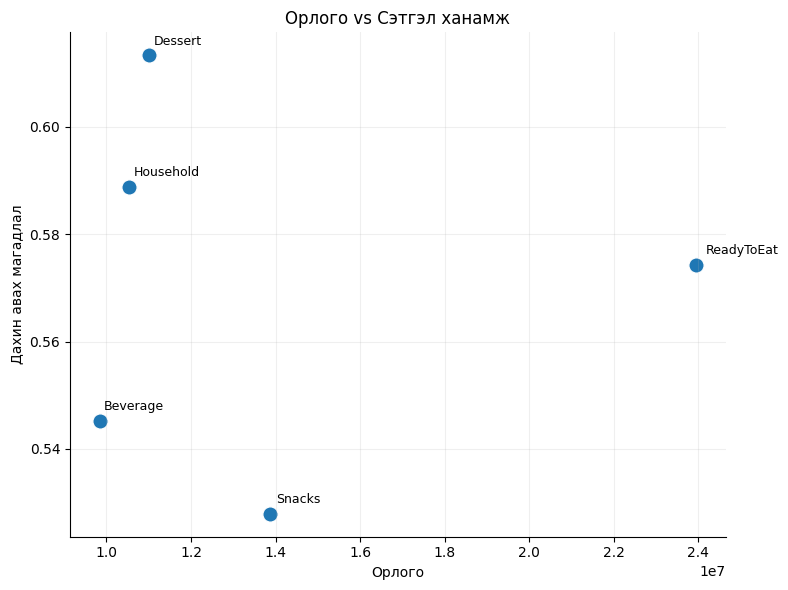

In [170]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=cat_full,
    x='revenue',
    y='buy_again_rate',
    s=120
)

# clean labels (slight offset)
for i in range(len(cat_full)):
    plt.text(
        cat_full['revenue'][i] * 1.01,
        cat_full['buy_again_rate'][i] + 0.002,
        cat_full['category_name'][i],
        fontsize=9
    )

plt.xlabel("Орлого")
plt.ylabel("Дахин авах магадлал")
plt.title("Орлого vs Сэтгэл ханамж")

# minimal clean style
sns.despine()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Dessert ангилал нь харьцангуй бага орлоготой хэдий ч хамгийн өндөр buy-again rate (~61%) үзүүлж байна. Энэ нь уг ангилалд өсөлтийн боломж байгааг илтгэнэ.

Beverage ангилал өндөр discount ашиглаж байгаа ч орлогын хувьд доогуур байгаа нь discount стратеги үр ашиггүй байж болзошгүйг харуулж байна.